## qsoabsfind example notebook

Below I show a few examples to run `qsoabsfind` explore its output.

In [1]:
# imports
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt

### Details of input file (SDSS Spectra)

In [2]:
# exploring ..data/sdss/qso_test_spectra.fits file
hdul = fits.open(f'../data/sdss/qso_test_spectra.fits')
hdul[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
SURVEY  = 'SDSS    '                                                            
TARGET  = 'QSO     '                                                            
DR      = '16      '                                                            
AUTHOR  = 'Abhijeet Anand'                                                      

In [3]:
hdul.close()

### Running qsoabsfind as bash script

In [ ]:
# #!/bin/bash

# # Loop over absorber types
# for absorber in MgII CIV; do
#   echo "Running qsoabsfind for $absorber..."

#   qsoabsfind \
#     --input-fits-file ../data/sdss/qso_test_spectra.fits \
#     --absorber ${absorber} \
#     --output ../data/sdss/${absorber}_cat.fits \
#     --headers AUTHOR=A.Anand SURVEY=SDSS DR=16 \
#     --ncpus 8 \
#     --coldens \
#     --dv 300 \
#     --constant-file ../data/sdss/sdss_constants.py \
#     >> ../data/sdss/logs/${absorber}.log

#   echo "Finished $absorber"
# done


- I have already run `qsoabsfind` on `../data/sdss/qso_test_spectra.fits` and saved the results as `../data/sdss/MgII_cat.fits` and `../data/sdss/CIV_cat.fits`. Corresponding Log files are also saved.

### Exploring output

Text(0.5, 0, 'MgII redshift')

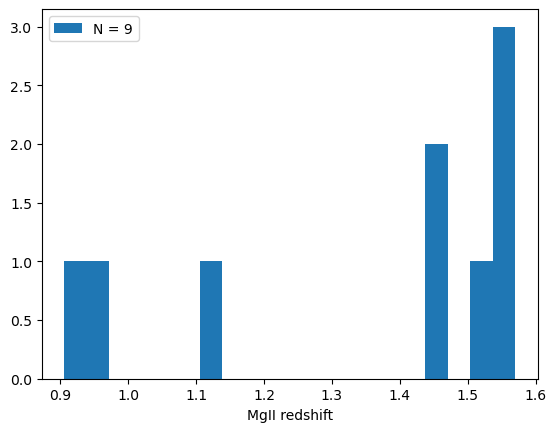

In [6]:
mgii_tab = Table.read(f'../data/sdss/MgII_cat.fits', hdu=1)
zabs = mgii_tab["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('MgII redshift')

Text(0.5, 0, '$EW_{\\rm MgII}\\, [\\AA]$')

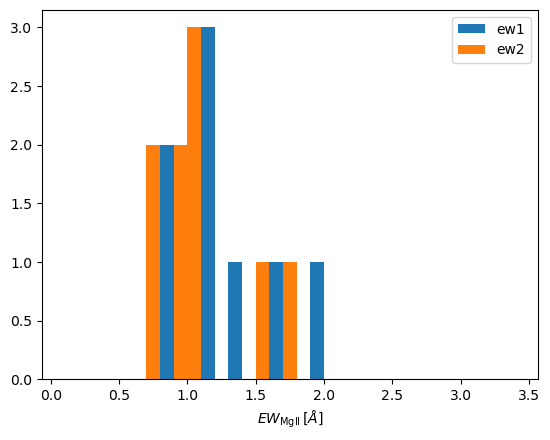

In [7]:
ew1 = mgii_tab["MGII_2796_EW"].data
ew2 = mgii_tab["MGII_2803_EW"].data
bins = np.arange(0.1, 3.5, 0.1)
plt.hist(ew1, bins=bins, label='ew1')
plt.hist(ew2, bins=bins, label = 'ew2')
plt.legend()
plt.xlabel(r'$EW_{\rm MgII}\, [\AA]$')

### Plotting spectra

INFO: plotting QSO INDEX = 6...
INFO: Time taken to read ../data/sdss/qso_test_spectra.fits 0.03 seconds


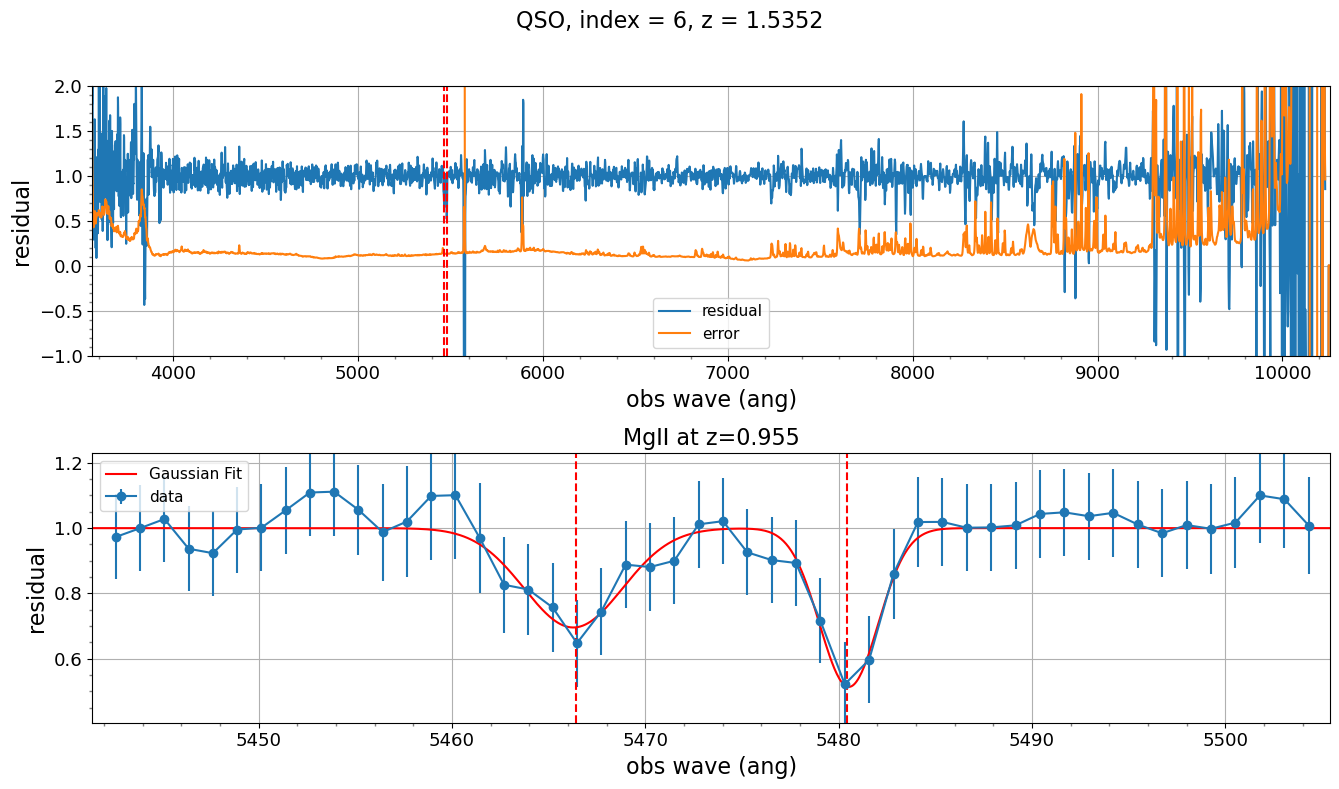

In [8]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.spec import QSOSpecRead
import numpy as np

# select a random spectra from MgII_cat.fits
index = np.random.choice(mgii_tab["INDEX_SPEC"].data)
print(f'INFO: plotting QSO INDEX = {index}...')
spectra = QSOSpecRead(f'../data/sdss/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = mgii_tab[mgii_tab["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'MgII', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)

### Using qsoabsfind internally as module

In [9]:
# if want to run qsoabsfind on one spectrum
from qsoabsfind.absfinder import read_single_spectrum_and_find_absorber
from qsoabsfind.constants import search_parameters
help(read_single_spectrum_and_find_absorber)

Help on function read_single_spectrum_and_find_absorber in module qsoabsfind.absfinder:

read_single_spectrum_and_find_absorber(fits_file, spec_index, absorber, **kwargs)
    This function retrieves a single QSO spectrum from a FITS file, processes the data to remove NaNs,
    and prepares the spectrum for absorber search within specified wavelength regions
    and runs the convolution based adaptive S/N method to detect absorbers in the spectrum.
    
    Args:
        fits_file (str): Path to the FITS file containing normalized QSO spectra.
                         The file must include extensions for FLUX, ERROR, WAVELENGTH
                         and METADATA which must contain keyword Z_QSO.
        spec_index (int): Index of the quasar spectrum to retrieve from the FITS file.
        absorber (str): Name of the absorber to search for (e.g., MgII, CIV, OVI, NV, SiIV, AlIII, FeII).
        kwargs (dict): search parameters as described in qsoabsfind.constants()
    
    Returns:
  

In [10]:
read_single_spectrum_and_find_absorber(f'../data/sdss/qso_test_spectra.fits', 6, 'MgII', **search_parameters["MgII"])


INFO: Starting search for QSO INDEX = 6
INFO: Time taken to read ../data/sdss/qso_test_spectra.fits 0.03 seconds
INFO: using default wavelength search window
INFO: wavelength search window in quasar-rest frame: (1549.48, 2799.117) Angstroms
INFO: final wave window selection for MgII took 0.00 seconds
INFO: search absorber = MgII
INFO: Z_QSO = 1.5351601839065552
INFO: instrumental resolution will be calculated from wavelength array, it is assumed that wavelength pixels are less than FWHM, so will not divide by 2.355
INFO: mean wave_resolution = 0.00010, mean resolution per pixel  = 69.015 [km/s]
INFO: Time taken to finish MgII detection for index = 6 Quasar is: 4.38 seconds
-------



([6],
 [0.9548317296937145],
 [[0.3042674750761455,
   2796.290068195723,
   1.3013816718737812,
   0.48617490261252616,
   2803.5800854750305,
   0.7728019435006942]],
 [[0.08736242956061985,
   0.44469004452576777,
   0.4561195248093021,
   0.10994528091400559,
   0.2051935501663808,
   0.20583584733790347]],
 [0.9925448894500732],
 [0.9417826533317566],
 [1.934327483177185],
 [0.06289248168468475],
 [0.03786586970090866],
 [0.07341177761554718],
 [0.0001711063669063151],
 [3.7430020785598317],
 [4.0594311832948895],
 [121.36877961779055],
 [45.55616020188784])

Text(0.5, 0, 'CIV redshift')

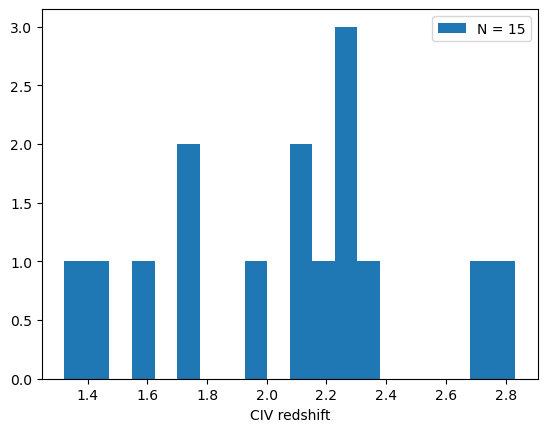

In [11]:
abs_tab = Table.read(f'../data/sdss/CIV_cat.fits', hdu=1)
zabs = abs_tab["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('CIV redshift')

INFO: plotting CIV for QSO INDEX = 61...
INFO: Time taken to read ../data/sdss/qso_test_spectra.fits 0.02 seconds


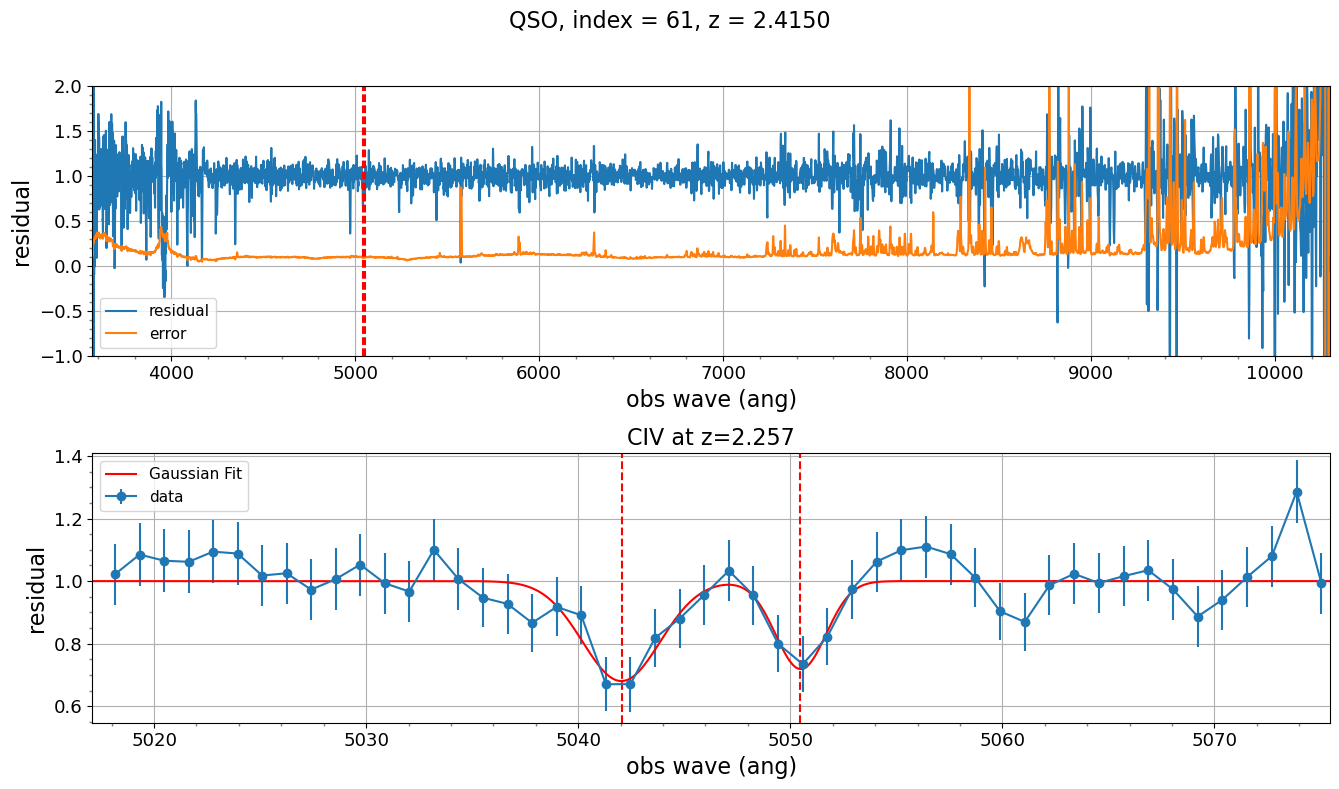

In [12]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.spec import QSOSpecRead

# select a random spectra from MgII_cat.fits
index = np.random.choice(abs_tab["INDEX_SPEC"].data)
print(f'INFO: plotting CIV for QSO INDEX = {index}...')
spectra = QSOSpecRead(f'../data/sdss/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = abs_tab[abs_tab["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'CIV', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)